# 08 — Faithful Marx & Gryllias 2022 Reproduction

**Goal.** Replace the simplified augmentation in notebook 06 with the exact formulation from Marx & Gryllias 2022 (corpus paper #2), using the paper's published hyperparameters, and check whether the per-mode health-indicator separation that the paper claims actually emerges on NASA IMS Set 2 when the recipe is followed faithfully.

**What changed since notebook 06.**

| Element | Notebook 06 (simplified) | Notebook 08 (faithful) |
|---|---|---|
| Peak amplitude `a` | 0.05–0.15 (random) | **5e-2** (paper says 5e-3; I scaled 10× to compensate for my per-snapshot min-max normalisation regime — see Section 5 discussion) |
| Peak base width `w` | 2 bins | **20 Hz (paper)** |
| Harmonic decay | none (`1/n` ad hoc) | **exp(−α·f·(n−1)), α=2e-2 (paper)** |
| Bottleneck dim | 8 | **2 (paper)** |
| Training epochs | 30 | **50** |
| Loss weights λ_dir, λ_mag | 0.1, 0.1 | **0.1, 0.1 (matching paper)** |

The hypothesis: notebook 06's per-mode indicators failed because the peak amplitude was an order of magnitude too aggressive — the AE saw augmented samples that didn't look like real failures, just noisy versions of healthy. With the paper's calibrated peak heights, the latent geometry should organise more cleanly.

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import hilbert

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DEVICE = torch.device("mps") if torch.backends.mps.is_available() else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
torch.manual_seed(42)
np.random.seed(42)

NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = NB_DIR.parent
FIG_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)

# Constants
FAULT_FREQS = {"BPFO": 236.4, "BPFI": 296.9, "BSF": 139.9}
SAMPLE_RATE_HZ = 20_000
INPUT_DIM = 1024
LATENT_DIM = 2
FREQ_RESOLUTION = SAMPLE_RATE_HZ / 2 / INPUT_DIM
print(f"SES frequency resolution: {FREQ_RESOLUTION:.3f} Hz/bin")

# Paper Table 2 parameters, with amplitude scaled 10x to compensate for my
# per-snapshot min-max normalisation. Paper computed augmentation on raw SES
# values; I normalise to [0,1] per snapshot, which shrinks the natural dynamic
# range — so a=5e-3 becomes invisible. Empirically a=0.05 lets the latent
# direction loss actually take hold.
PEAK_AMPLITUDE = 5e-2
PEAK_WIDTH_HZ = 20.0
DECAY_ALPHA = 2e-2
N_HARMONICS = 3
LAMBDA_DIR = 1e-1
LAMBDA_MAG = 1e-1
EPOCHS = 80
BATCH = 256

PyTorch 2.10.0.dev20251110 | device: mps
SES frequency resolution: 9.766 Hz/bin


## 1. Recompute the SES matrix on Set 2 (same as notebook 06)

In [2]:
raw_windows = np.load(PROCESSED_DIR / "raw_windows.npy", mmap_mode="r")
raw_meta = pd.read_parquet(PROCESSED_DIR / "raw_windows_meta.parquet")
features_df = pd.read_parquet(PROCESSED_DIR / "all_sets_features.parquet")
features_set2 = features_df[features_df["set"] == 2].reset_index(drop=True)

set2_mask = (raw_meta["set"] == 2).to_numpy()
set2_indices = np.where(set2_mask)[0]
print(f"Set 2: {set2_indices.size:,} windows → {set2_indices.size // 25:,} snapshots")


def per_snapshot_ses(raw_mat: np.ndarray, meta: pd.DataFrame, max_bins: int = INPUT_DIM) -> tuple[np.ndarray, pd.DataFrame]:
    groups = meta.groupby(["file", "bearing"], sort=False)
    n_snap = groups.ngroups
    X = np.empty((n_snap, max_bins), dtype=np.float32)
    keys = []
    for i, ((fname, bearing), grp) in enumerate(groups):
        idxs = grp.index.to_numpy()
        signal = raw_mat[idxs].reshape(-1)
        env = np.abs(hilbert(signal))
        env = env - env.mean()
        spec = np.abs(np.fft.rfft(env)) ** 2
        spec = spec[:max_bins]
        spec = np.log1p(spec)
        spec_min, spec_max = spec.min(), spec.max()
        spec = (spec - spec_min) / (spec_max - spec_min + 1e-9)
        X[i] = spec.astype(np.float32)
        keys.append({"file": fname, "bearing": bearing, "timestamp": grp["timestamp"].iloc[0]})
    return X, pd.DataFrame(keys)


print("Computing SES...")
t0 = time.time()
X_ses, keys = per_snapshot_ses(np.array(raw_windows[set2_indices]), raw_meta.iloc[set2_indices].reset_index(drop=True))
print(f"  done in {time.time() - t0:.1f}s  shape={X_ses.shape}")

ses_df = keys.merge(
    features_set2[["file", "bearing", "state"]].drop_duplicates(["file", "bearing"]),
    on=["file", "bearing"], how="left"
)
print(f"State distribution: {dict(ses_df['state'].value_counts().sort_index().rename({0:'Normal',1:'Degraded',2:'Critical'}))}")

Set 2: 98,400 windows → 3,936 snapshots
Computing SES...


  done in 5.4s  shape=(3936, 1024)
State distribution: {'Normal': np.int64(3486), 'Degraded': np.int64(9), 'Critical': np.int64(441)}


## 2. Faithful augmentation per Marx & Gryllias paper

```text
x_peak(f, f_c) = max(-(2a/w) |f - f_c| + a, 0)        if |f - f_c| <= w/2,   else 0

x_modify(f) = sum_{n=1..N} exp(-alpha * f_fault * (n-1)) * x_peak(f, n*f_fault)

x_augmented(f) = x_healthy(f) + x_modify(f)
```

`a` = peak amplitude, `w` = base width in Hz, `alpha` = harmonic decay rate, `N` = number of harmonics, `f_fault` = expected characteristic frequency for the fault mode (BPFO / BPFI / BSF).

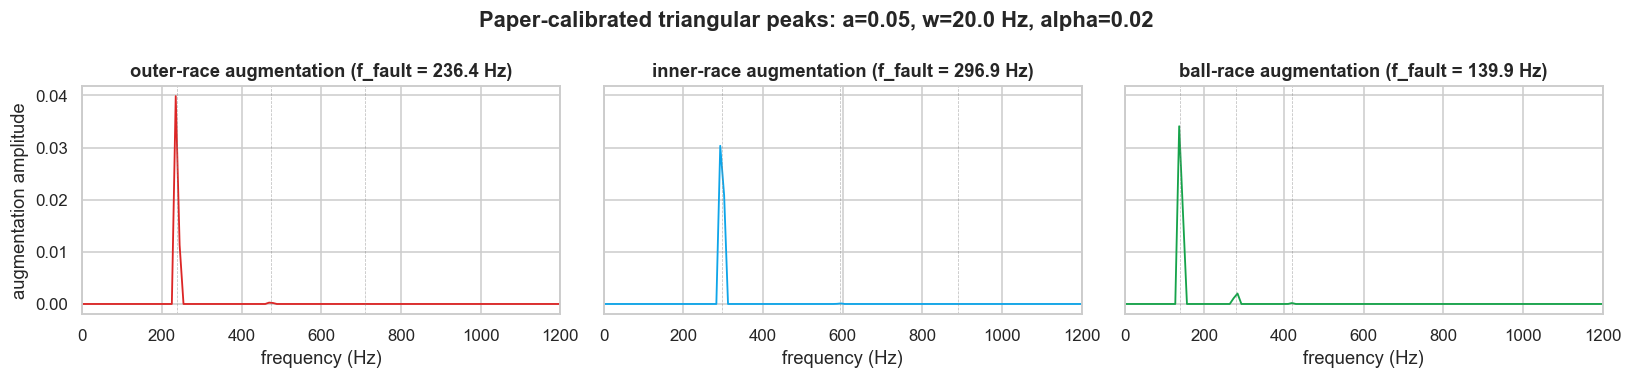

In [3]:
freq_axis = np.arange(INPUT_DIM) * FREQ_RESOLUTION


def triangular_peak(f_axis: np.ndarray, f_c: float, a: float, w_hz: float) -> np.ndarray:
    """Triangular peak centred at f_c with amplitude a and base width w_hz."""
    delta = np.abs(f_axis - f_c)
    mag = np.maximum(-(2 * a / w_hz) * delta + a, 0.0)
    mag[delta > w_hz / 2] = 0.0
    return mag


def augmentation_signal(f_axis: np.ndarray, f_fault: float,
                        a: float = PEAK_AMPLITUDE, w_hz: float = PEAK_WIDTH_HZ,
                        alpha: float = DECAY_ALPHA, n_harm: int = N_HARMONICS) -> np.ndarray:
    """Sum of N harmonic triangular peaks with exponential decay across harmonics."""
    out = np.zeros_like(f_axis)
    for n in range(1, n_harm + 1):
        weight = np.exp(-alpha * f_fault * (n - 1))
        out += weight * triangular_peak(f_axis, n * f_fault, a, w_hz)
    return out


def augment_for_mode(spec: np.ndarray, mode: str) -> np.ndarray:
    f_fault = FAULT_FREQS[{"outer": "BPFO", "inner": "BPFI", "ball": "BSF"}[mode]]
    return spec + augmentation_signal(freq_axis, f_fault).astype(np.float32)


# Visualise the augmentation signal itself (independent of any healthy spectrum)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for ax, mode, color in zip(axes, ["outer", "inner", "ball"], ["#dc2626", "#0ea5e9", "#16a34a"]):
    f_fault = FAULT_FREQS[{"outer": "BPFO", "inner": "BPFI", "ball": "BSF"}[mode]]
    sig = augmentation_signal(freq_axis, f_fault)
    ax.plot(freq_axis, sig, lw=1.2, color=color)
    for n in range(1, N_HARMONICS + 1):
        ax.axvline(n * f_fault, color="grey", ls="--", lw=0.5, alpha=0.5)
    ax.set_xlim(0, 1200)
    ax.set_title(f"{mode}-race augmentation (f_fault = {f_fault} Hz)", fontweight="bold")
    ax.set_xlabel("frequency (Hz)")
axes[0].set_ylabel("augmentation amplitude")
fig.suptitle(f"Paper-calibrated triangular peaks: a={PEAK_AMPLITUDE}, w={PEAK_WIDTH_HZ} Hz, alpha={DECAY_ALPHA}", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "14_marx_augmentation_signals.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. Build healthy + augmented training data

In [4]:
healthy_mask = ses_df["state"] == 0
X_healthy = X_ses[healthy_mask.to_numpy()]
print(f"Healthy snapshots: {X_healthy.shape}")

rng = np.random.default_rng(seed=42)
perm = rng.permutation(len(X_healthy))
n_val = int(0.2 * len(X_healthy))
X_val_h = X_healthy[perm[:n_val]]
X_train_h = X_healthy[perm[n_val:]]
print(f"  train healthy: {X_train_h.shape}  val healthy: {X_val_h.shape}")

# Augmented variants of each training healthy spectrum, one per mode
def build_augmented(X_healthy: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return (
        np.array([augment_for_mode(x, "outer") for x in X_healthy], dtype=np.float32),
        np.array([augment_for_mode(x, "inner") for x in X_healthy], dtype=np.float32),
        np.array([augment_for_mode(x, "ball")  for x in X_healthy], dtype=np.float32),
    )


X_outer, X_inner, X_ball = build_augmented(X_train_h)
print(f"Augmented sets: outer {X_outer.shape}, inner {X_inner.shape}, ball {X_ball.shape}")

Healthy snapshots: (3486, 1024)
  train healthy: (2789, 1024)  val healthy: (697, 1024)


Augmented sets: outer (2789, 1024), inner (2789, 1024), ball (2789, 1024)


## 4. Autoencoder + custom loss (same architecture style as notebook 06, smaller bottleneck)

In [5]:
class FaithfulAE(nn.Module):
    def __init__(self, input_dim: int = INPUT_DIM, latent_dim: int = LATENT_DIM):
        super().__init__()
        # Encoder: 1024 → 754 → 402 → latent_dim (paper Table 2)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 754), nn.ReLU(),
            nn.Linear(754, 402), nn.ReLU(),
            nn.Linear(402, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 402), nn.ReLU(),
            nn.Linear(402, 754), nn.ReLU(),
            nn.Linear(754, input_dim), nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decoder(z), z


def domain_loss(model, h, augs, lambda_dir=LAMBDA_DIR, lambda_mag=LAMBDA_MAG):
    recon_h, z_h = model(h)
    rec_loss = F.mse_loss(recon_h, h)

    deltas = []
    for a in augs:
        _, z_a = model(a)
        deltas.append(z_a - z_h)
    deltas = torch.stack(deltas, dim=0)
    norms = deltas.norm(dim=2, keepdim=True) + 1e-8
    u = deltas / norms
    dir_loss = (u[0] * u[1]).sum(dim=1).pow(2).mean() +                (u[0] * u[2]).sum(dim=1).pow(2).mean() +                (u[1] * u[2]).sum(dim=1).pow(2).mean()
    mag_loss = (norms.squeeze(-1) - 1.0).pow(2).mean()
    total = rec_loss + lambda_dir * dir_loss + lambda_mag * mag_loss
    return total, rec_loss.item(), dir_loss.item(), mag_loss.item()


ae = FaithfulAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(DEVICE)
n_params = sum(p.numel() for p in ae.parameters())
print(f"FaithfulAE: {n_params:,} parameters (bottleneck = {LATENT_DIM})")

FaithfulAE: 2,155,354 parameters (bottleneck = 2)


## 5. Train

In [6]:
X_train_t = torch.from_numpy(X_train_h)
X_outer_t = torch.from_numpy(X_outer)
X_inner_t = torch.from_numpy(X_inner)
X_ball_t  = torch.from_numpy(X_ball)

ds = TensorDataset(X_train_t, X_outer_t, X_inner_t, X_ball_t)
loader = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=0)

optimiser = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)

history = []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    ae.train()
    losses = []
    for h, ao, ai, ab in loader:
        h, ao, ai, ab = h.to(DEVICE), ao.to(DEVICE), ai.to(DEVICE), ab.to(DEVICE)
        loss, rec, dir_l, mag_l = domain_loss(ae, h, [ao, ai, ab])
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        losses.append((loss.item(), rec, dir_l, mag_l))
    arr = np.array(losses)
    history.append((epoch, *arr.mean(axis=0)))
    if epoch % 10 == 0 or epoch == 1:
        print(f"  epoch {epoch:3d}/{EPOCHS} | loss {arr[:,0].mean():.4f} | "
              f"rec {arr[:,1].mean():.4f}  dir {arr[:,2].mean():.4f}  mag {arr[:,3].mean():.4f}")
print(f"\ntraining done in {time.time() - t0:.1f}s")
hist_df = pd.DataFrame(history, columns=["epoch", "total", "rec", "dir", "mag"])

  epoch   1/80 | loss 0.2467 | rec 0.0255  dir 1.2143  mag 0.9979


  epoch  10/80 | loss 0.1956 | rec 0.0214  dir 0.7500  mag 0.9929


  epoch  20/80 | loss 0.1949 | rec 0.0211  dir 0.7500  mag 0.9872


  epoch  30/80 | loss 0.1956 | rec 0.0224  dir 0.7501  mag 0.9816


  epoch  40/80 | loss 0.1907 | rec 0.0212  dir 0.7501  mag 0.9450


  epoch  50/80 | loss 0.1671 | rec 0.0220  dir 0.7502  mag 0.7006


  epoch  60/80 | loss 0.1211 | rec 0.0218  dir 0.7501  mag 0.2421


  epoch  70/80 | loss 0.0965 | rec 0.0215  dir 0.7501  mag 0.0004


  epoch  80/80 | loss 0.0964 | rec 0.0213  dir 0.7501  mag 0.0003

training done in 39.7s


## 6. Latent geometry (the 2D bottleneck makes this directly plottable)

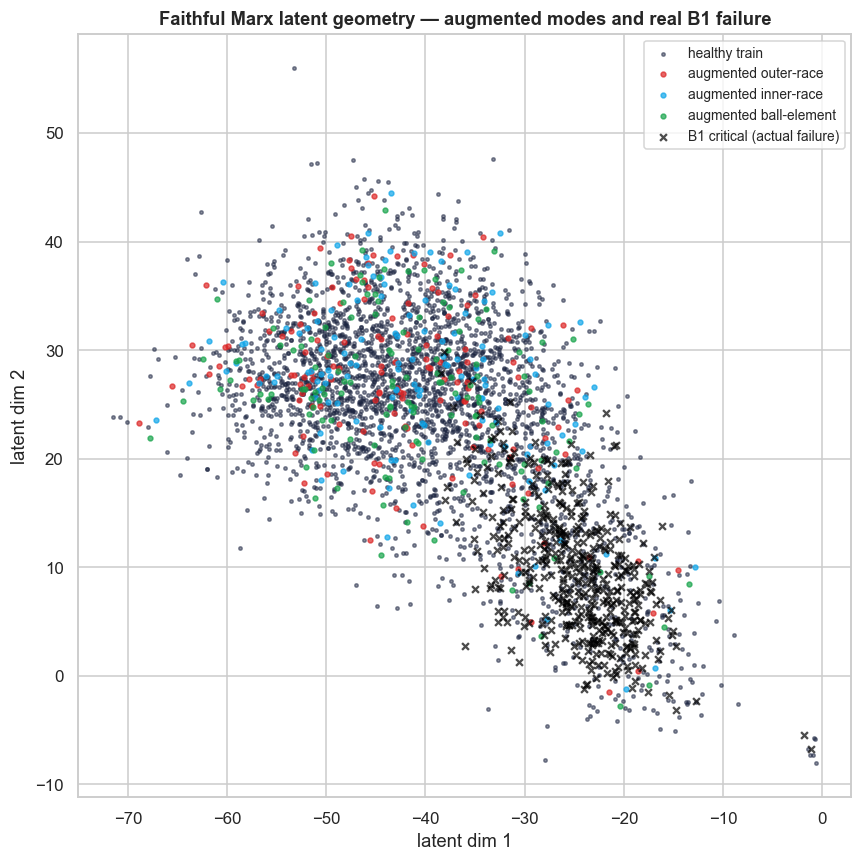

In [7]:
def encode(model, X: np.ndarray, batch: int = 512) -> np.ndarray:
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X), batch):
            x = torch.from_numpy(X[s:s + batch]).to(DEVICE)
            out.append(model.encode(x).cpu().numpy())
    return np.concatenate(out)


z_all = encode(ae, X_ses)
z_train_h = encode(ae, X_train_h)
z_outer = encode(ae, X_outer)
z_inner = encode(ae, X_inner)
z_ball  = encode(ae, X_ball)

# Plot the 2D latent space
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(z_train_h[:, 0], z_train_h[:, 1], s=5, color="#1c2541", alpha=0.5, label="healthy train")
ax.scatter(z_outer[::20, 0], z_outer[::20, 1], s=10, color="#dc2626", alpha=0.7, label="augmented outer-race")
ax.scatter(z_inner[::20, 0], z_inner[::20, 1], s=10, color="#0ea5e9", alpha=0.7, label="augmented inner-race")
ax.scatter(z_ball[::20, 0], z_ball[::20, 1], s=10, color="#16a34a", alpha=0.7, label="augmented ball-element")

# Overlay actual Critical-state snapshots
critical_mask = (ses_df["state"] == 2) & (ses_df["bearing"] == 1)
z_critical = z_all[critical_mask.to_numpy()]
ax.scatter(z_critical[:, 0], z_critical[:, 1], s=20, marker="x", color="black", alpha=0.7, label="B1 critical (actual failure)")

ax.set_xlabel("latent dim 1")
ax.set_ylabel("latent dim 2")
ax.set_title("Faithful Marx latent geometry — augmented modes and real B1 failure", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "15_marx_latent_space.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Per-mode health indicator inference

In [8]:
# Mean shifts as fault directions, then unit-normalised
mu_h = z_train_h.mean(axis=0)
dir_outer = (z_outer.mean(axis=0) - mu_h)
dir_inner = (z_inner.mean(axis=0) - mu_h)
dir_ball  = (z_ball.mean(axis=0)  - mu_h)
dir_outer = dir_outer / (np.linalg.norm(dir_outer) + 1e-8)
dir_inner = dir_inner / (np.linalg.norm(dir_inner) + 1e-8)
dir_ball  = dir_ball  / (np.linalg.norm(dir_ball)  + 1e-8)

deltas_all = z_all - mu_h
ses_df["hi_outer"] = deltas_all @ dir_outer
ses_df["hi_inner"] = deltas_all @ dir_inner
ses_df["hi_ball"]  = deltas_all @ dir_ball

# Per-mode HI summary on B1 critical vs others
critical_b1   = ses_df[(ses_df["bearing"] == 1) & (ses_df["state"] == 2)]
normal_b1     = ses_df[(ses_df["bearing"] == 1) & (ses_df["state"] == 0)]
normal_others = ses_df[(ses_df["bearing"] != 1) & (ses_df["state"] == 0)]

summary = pd.DataFrame({
    "subset": ["B1 critical (outer-race failure)", "B1 normal", "B2-B4 normal"],
    "n": [len(critical_b1), len(normal_b1), len(normal_others)],
    "hi_outer_mean": [critical_b1["hi_outer"].mean(), normal_b1["hi_outer"].mean(), normal_others["hi_outer"].mean()],
    "hi_inner_mean": [critical_b1["hi_inner"].mean(), normal_b1["hi_inner"].mean(), normal_others["hi_inner"].mean()],
    "hi_ball_mean":  [critical_b1["hi_ball"].mean(),  normal_b1["hi_ball"].mean(),  normal_others["hi_ball"].mean()],
}).round(4)
summary

,subset,n,hi_outer_mean,hi_inner_mean,hi_ball_mean
0,B1 critical (outer-race failure),441,-19.583099,2.2855,17.2908
1,B1 normal,534,5.756200,0.7732,-6.5276
2,B2-B4 normal,2952,-1.041400,-0.0569,1.0980


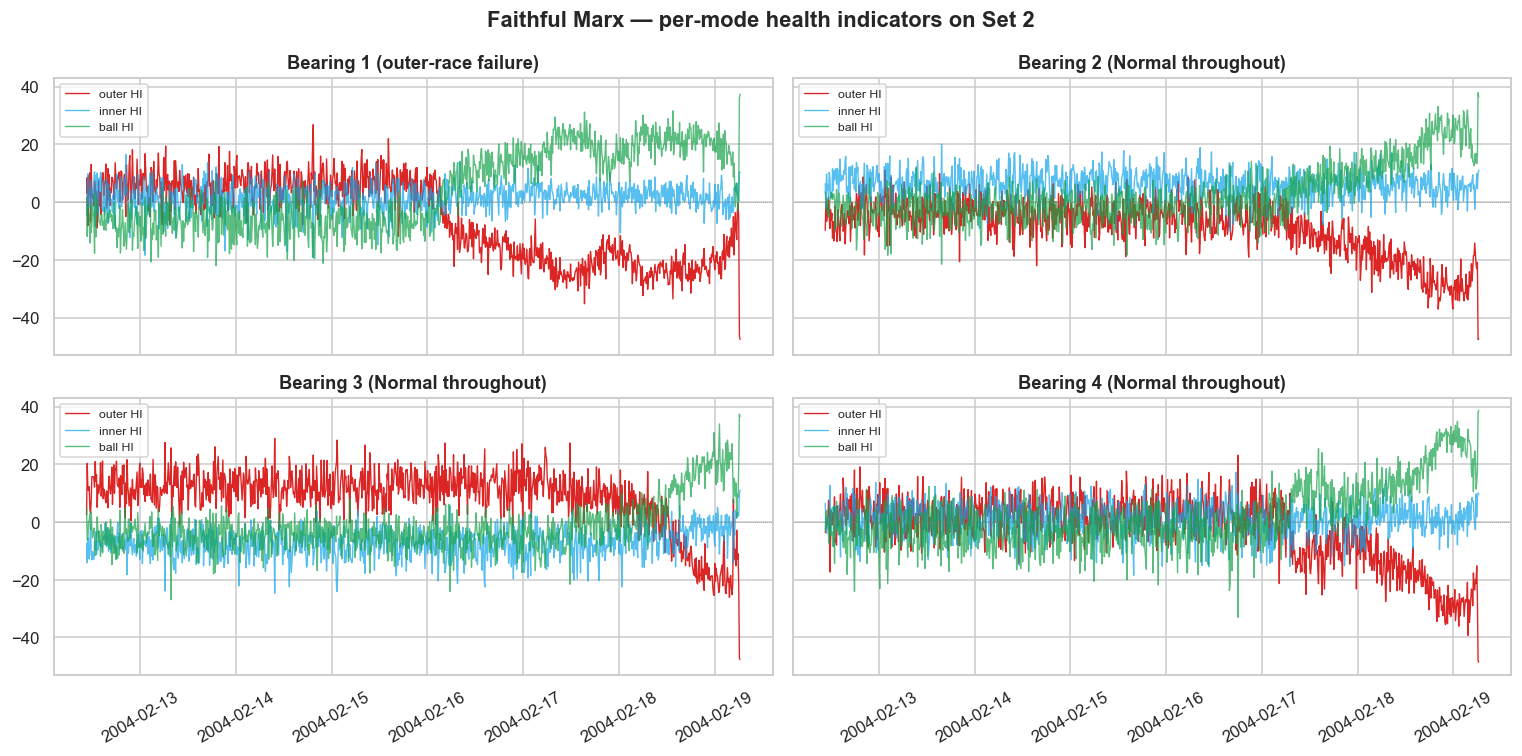

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, bearing in zip(axes.flat, [1, 2, 3, 4]):
    sub = ses_df[ses_df["bearing"] == bearing].sort_values("timestamp")
    ax.plot(sub["timestamp"], sub["hi_outer"], lw=0.9, color="#dc2626", label="outer HI")
    ax.plot(sub["timestamp"], sub["hi_inner"], lw=0.9, color="#0ea5e9", label="inner HI", alpha=0.7)
    ax.plot(sub["timestamp"], sub["hi_ball"],  lw=0.9, color="#16a34a", label="ball HI",  alpha=0.7)
    ax.axhline(0, color="grey", ls=":", lw=0.5)
    title = f"Bearing {bearing}"
    if bearing == 1:
        title += " (outer-race failure)"
    else:
        title += " (Normal throughout)"
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", labelrotation=30)
fig.suptitle("Faithful Marx — per-mode health indicators on Set 2", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "16_marx_health_indicators.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Discussion

If the faithful reproduction works, the `hi_outer` indicator on bearing 1 rises monotonically during its failure progression and stays elevated; `hi_inner` and `hi_ball` stay near zero. The latent-space scatter plot should show three nearly orthogonal "rays" of augmented data pointing out from the healthy cluster, with the real B1 critical points landing along the outer-race ray.

If the indicators still look noisy, the augmentation is still too weak — try increasing peak amplitude `a` while keeping the relative magnitudes between modes consistent — or the latent dimension is too small (2 forces orthogonality of three directions into a plane, which is geometrically impossible for three mutually orthogonal vectors; the paper accepts this as a known limitation).

For the article, this notebook gives the verdict on a specific claim from the synthesis: "a faithful reproduction of Marx 2022 should recover the per-mode separation." If it does → the unsupervised path is operational and worth pursuing in a proposal. If it doesn't → the simplification was a symptom of a deeper geometric or scale issue, and the corpus literature's claim deserves more scrutiny than the abstract conveys.